# Stanford CME 241 (Winter 2026) - Assignment 3

**Due: Friday, February 27 @ 11:59 PM PST on Gradescope.**

Assignment instructions:
- Make sure each of the subquestions have answers
- Ensure that group members indicate which problems they're in charge of
- Show work and walk through your thought process where applicable
- Empty code blocks are for your use, so feel free to create more under each section as needed
- Document code with light comments (i.e. 'this function handles visualization')

Submission instructions:
- When complete, fill out your publicly available GitHub repo file URL and group members below, then export or print this .ipynb file to PDF and upload the PDF to Gradescope.

*Link to this ipynb file in your public GitHub repo (replace below URL with yours):* 

https://github.com/ziyigao4/RL-book/blob/master/assignments/assignment3.ipynb

*Group members (replace below names with people in your group):* 
- Person 1
- Person 2
- Person 3

## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from typing import Iterable, Iterator, Mapping, TypeVar, Callable, Sequence, Tuple, Dict

import os, sys
sys.path.append(os.path.abspath(".."))

from rl.distribution import Categorical
from rl.markov_process import FiniteMarkovRewardProcess
from rl.chapter10.prediction_utils import compare_td_and_mc
X = TypeVar('X')
S = TypeVar('S')

## Question 1: Milk Vendor Optimization Problem (Led by ______)

You are a milk vendor and your task is to bring to your store a supply (denoted $S \in \mathbb{R}$) of milk volume in the morning that will give you the best profits. You know that the demand for milk throughout the course of the day is a probability distribution function $f$ (for mathematical convenience, assume people can buy milk in volumes that are real numbers, hence milk demand $x \in \mathbb{R}$ is a continuous variable with a probability density function). 

For every extra gallon of milk you carry at the end of the day (supply $S$ exceeds random demand $x$), you incur a cost of $h$ (effectively the wasteful purchases amounting to the difference between your purchase price and the end-of-day discount disposal price since you are not allowed to sell the same milk the next day). For every gallon of milk that a customer demands that you don’t carry (random demand $x$ exceeds supply $S$), you incur a cost of $p$ (effectively the missed sales revenue amounting to the difference between your sales price and purchase price). 

Your task is to identify the optimal supply $S$ that minimizes your **Expected Cost** $g(S)$, given by:

$$
g_1(S) = \mathbb{E}[\max(x - S, 0)] = \int_{S}^{\infty} (x - S) \cdot f(x) \, dx
$$

$$
g_2(S) = \mathbb{E}[\max(S - x, 0)] = \int_{-\infty}^{S} (S - x) \cdot f(x) \, dx
$$

$$
g(S) = p \cdot g_1(S) + h \cdot g_2(S)
$$

---

### Part (A): Analytical Optimization

1. **Derive the first-order condition (FOC)** for minimizing the expected cost $g(S)$.
2. **Solve the FOC** to express the optimal supply $S^*$ in terms of the given parameters: $p$, $h$, and the demand distribution $f(x)$. (*Hint*: Pay attention to the balance between the costs of overstocking and understocking)

3. **Interpretation**: Provide an interpretation of the condition you derived. What does the balance between $p$ and $h$ imply about the optimal supply $S^*$?

---

### Part (B): Special Case Analysis

1. Consider the case where the demand $x$ follows an **exponential distribution** with parameter $\lambda > 0$. That is, $f(x) = \lambda e^{-\lambda x}$ for $x \geq 0$.
    - Derive an explicit expression for the optimal supply $S^*$.
    
2. Consider the case where the demand $x$ follows a **normal distribution** with mean $\mu$ and variance $\sigma^2$, i.e., $x \sim \mathcal{N}(\mu, \sigma^2)$. 
    - Set up the integral for $g(S)$ and describe how it relates to the **cumulative distribution function (CDF)** of the normal distribution.
    - Provide an interpretation of how changes in $\mu$ and $\sigma$ influence the optimal $S^*$. 

---

### Part (C): Framing as a Financial Options Problem

1. Frame the milk vendor’s problem as a **portfolio of call and put options**:
    - Identify the analog of the “strike price” and “underlying asset.”
    - Explain which part of the cost function $g_1(S)$ or $g_2(S)$ corresponds to a call option and which part to a put option.
    - What do $p$ and $h$ represent in this options framework?

2. Explain how this framing could be used to derive the optimal supply $S^*$ if solved using financial engineering concepts.

---

### Part (D): Numerical Solution and Simulation

1. **Numerical Solution**: Write a Python function that numerically estimates the optimal $S^*$ using an iterative search or numerical optimization method. 

2. **Simulation**: Generate random samples of milk demand from an exponential distribution and simulate the total costs for different values of $S$. Plot the costs against $S$ and visually identify the optimal $S$.

### Part (A): Analytical Optimization

We want to choose $S$ to minimize
$$
g(S)=p\,g_1(S)+h\,g_2(S),
$$
where
$$
g_1(S)=\int_{S}^{\infty}(x-S)f(x)\,dx,\qquad
g_2(S)=\int_{-\infty}^{S}(S-x)f(x)\,dx.
$$

---

#### (A1) First-Order Condition (FOC)

Differentiate $g_1(S)$ using Leibniz rule:
$$
g_1(S)=\int_S^\infty (x-S)f(x)\,dx.
$$
Then
$$
\frac{d}{dS}g_1(S)
= -\int_S^\infty f(x)\,dx
=-(1-F(S)),
$$
where $F(S)=\int_{-\infty}^{S} f(x)\,dx$ is the CDF.

Differentiate $g_2(S)$:
$$
g_2(S)=\int_{-\infty}^{S}(S-x)f(x)\,dx,
$$
so
$$
\frac{d}{dS}g_2(S)
=\int_{-\infty}^{S} f(x)\,dx
=F(S).
$$

Therefore,
$$
g'(S)=p\,g_1'(S)+h\,g_2'(S)
=p\big(-(1-F(S))\big)+hF(S).
$$

FOC $g'(S)=0$ gives:
$$
-p(1-F(S))+hF(S)=0.
$$

---

#### (A2) Solve the FOC for $S^*$

Rearrange:
$$
-p + pF(S) + hF(S)=0
\quad\Rightarrow\quad
(p+h)F(S)=p
\quad\Rightarrow\quad
F(S^*)=\frac{p}{p+h}.
$$

Thus the optimal supply is the corresponding quantile:
$$
S^* = F^{-1}\!\left(\frac{p}{p+h}\right).
$$

---

#### (A3) Interpretation

The optimal supply $S^*$ is the $\frac{p}{p+h}$-quantile of demand.

- If the understock cost $p$ increases (missing sales becomes more expensive), then $\frac{p}{p+h}$ increases, so $S^*$ increases: you stock more to avoid shortages.
- If the overstock cost $h$ increases (waste becomes more expensive), then $\frac{p}{p+h}$ decreases, so $S^*$ decreases: you stock less to avoid leftovers.

So $S^*$ balances the marginal expected cost of understocking against the marginal expected cost of overstocking, yielding the classic “critical fractile” rule.

### Part (B): Special Case Analysis

Recall from Part (A) the critical-fractile condition:
$$
F(S^*)=\frac{p}{p+h}.
$$

---

#### (B1) Exponential Demand: $x \sim \text{Exponential}(\lambda)$

For $x \ge 0$, the CDF is
$$
F(x)=1-e^{-\lambda x}.
$$
Set $F(S^*)=\frac{p}{p+h}$:
$$
1-e^{-\lambda S^*}=\frac{p}{p+h}
\quad\Rightarrow\quad
e^{-\lambda S^*}=\frac{h}{p+h}.
$$
Taking logs:
$$
-\lambda S^*=\log\left(\frac{h}{p+h}\right)
\quad\Rightarrow\quad
S^*=\frac{1}{\lambda}\log\left(\frac{p+h}{h}\right)
=\frac{1}{\lambda}\log\left(1+\frac{p}{h}\right).
$$
(And $S^*\ge 0$ automatically.)

---

#### (B2) Normal Demand: $x \sim \mathcal{N}(\mu,\sigma^2)$

##### (i) Set up $g(S)$ and relate to the Normal CDF

The expected cost is
$$
g(S)=p\int_S^\infty (x-S)f(x)\,dx + h\int_{-\infty}^S (S-x)f(x)\,dx,
$$
where here
$$
f(x)=\frac{1}{\sigma\sqrt{2\pi}}\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right).
$$

Using the result from Part (A),
$$
g'(S)=-p(1-F(S))+hF(S),
$$
where now
$$
F(S)=\Phi\!\left(\frac{S-\mu}{\sigma}\right)
$$
and $\Phi(\cdot)$ is the standard normal CDF.  
So the optimality condition becomes
$$
\Phi\!\left(\frac{S^*-\mu}{\sigma}\right)=\frac{p}{p+h}.
$$
Equivalently,
$$
\frac{S^*-\mu}{\sigma}=\Phi^{-1}\!\left(\frac{p}{p+h}\right)
\quad\Rightarrow\quad
S^*=\mu+\sigma\,\Phi^{-1}\!\left(\frac{p}{p+h}\right).
$$

##### (ii) Interpretation: effect of $\mu$ and $\sigma$ on $S^*$

From
$$
S^*=\mu+\sigma\,z^*,\quad z^*=\Phi^{-1}\!\left(\frac{p}{p+h}\right),
$$
we see:

- Increasing $\mu$ shifts demand right, so $S^*$ increases **one-for-one** with $\mu$.
- Increasing $\sigma$ increases uncertainty, so $S^*$ moves **away from $\mu$** in the direction determined by $z^*$:
  - If $\frac{p}{p+h}>\tfrac12$ (understock cost relatively high, so $z^*>0$), then larger $\sigma$ increases $S^*$ (stock more to avoid shortages).
  - If $\frac{p}{p+h}<\tfrac12$ (overstock cost relatively high, so $z^*<0$), then larger $\sigma$ decreases $S^*$ (stock less to avoid leftovers).
  - If $\frac{p}{p+h}=\tfrac12$, then $z^*=0$ and $S^*=\mu$ regardless of $\sigma$.

### Part (C) Answer

### Part (C): Framing as a Financial Options Problem

Let the random demand be the “underlying”:
$$
X := x
$$
and treat the chosen supply level $S$ as the “strike”:
$$
K := S.
$$

---

#### (C1) Portfolio of call/put options

**Payoffs:**
- Understock amount:
$$
(x-S)^+ = \max(x-S,0)
$$
- Overstock amount:
$$
(S-x)^+ = \max(S-x,0)
$$

These are exactly option-style payoffs in the underlying $X$ with strike $K=S$:

- **Call option payoff** on underlying $X$ with strike $S$:
$$
\text{Call}(X;S) = (X-S)^+.
$$
So
$$
g_1(S)=\mathbb E[(x-S)^+]
$$
is the **expected call payoff**.

- **Put option payoff** on underlying $X$ with strike $S$:
$$
\text{Put}(X;S) = (S-X)^+.
$$
So
$$
g_2(S)=\mathbb E[(S-x)^+]
$$
is the **expected put payoff**.

Therefore the total expected cost is a **weighted portfolio**:
$$
g(S)=p\,\mathbb E[(X-S)^+] + h\,\mathbb E[(S-X)^+].
$$

**Interpretation of parameters:**
- $p$ is the per-unit **shortage penalty**, i.e. the weight on the call payoff $(X-S)^+$.
- $h$ is the per-unit **overage/holding penalty**, i.e. the weight on the put payoff $(S-X)^+$.

So in the options framework, $p$ and $h$ play the role of **positions (weights)** in a portfolio of a call and a put written on the same underlying $X$ with the same strike $S$.

---

#### (C2) Using this framing to derive $S^*$ (financial engineering intuition)

A key option identity is:
$$
(X-S)^+ - (S-X)^+ = X - S.
$$
Taking expectations gives:
$$
\mathbb E[(X-S)^+] - \mathbb E[(S-X)^+] = \mathbb E[X] - S.
$$

More importantly for optimization, the derivative of these expected option payoffs w.r.t. strike is:
$$
\frac{d}{dS}\mathbb E[(X-S)^+] = -\mathbb P(X>S)=-(1-F(S)),
$$
$$
\frac{d}{dS}\mathbb E[(S-X)^+] = \mathbb P(X\le S)=F(S).
$$

So the marginal effect of increasing the strike $S$ is:
- it **reduces** the expected call payoff by $(1-F(S))$,
- it **increases** the expected put payoff by $F(S)$.

Since
$$
g(S)=p\,\mathbb E[(X-S)^+] + h\,\mathbb E[(S-X)^+],
$$
we get
$$
g'(S)=p\cdot (-(1-F(S))) + h\cdot F(S).
$$
Setting $g'(S)=0$ yields:
$$
-p(1-F(S^*)) + hF(S^*)=0
\quad\Rightarrow\quad
F(S^*)=\frac{p}{p+h}.
$$

Thus the options framing leads directly to the same “critical fractile” condition:
$$
S^* = F^{-1}\!\left(\frac{p}{p+h}\right),
$$
by interpreting $S$ as the strike and balancing the marginal (probability-weighted) contributions of the call and put components in the cost portfolio.

### Part (D) Answer

In [20]:
'''
fill in the code below, and then run the code in the next cell for the simulation
'''

# simulation parameters
p = 5  # Cost of understocking (per unit)
h = 2  # Cost of overstocking (per unit)
lambda_param = 1.0  # Parameter for exponential distribution

# Probability density function for demand
def demand_pdf(x: float) -> float:
    if x < 0:
        return 0.0
    return lambda_param * np.exp(-lambda_param * x)

# Cumulative distribution function for demand
def demand_cdf(x: float) -> float:
    if x < 0:
        return 0.0
    return 1.0 - np.exp(-lambda_param * x)

# Expected cost function g(S)
def expected_cost(S: float) -> float:
    if S < 0:
        return np.inf

    g1 = p * (np.exp(-lambda_param * S) / lambda_param)
    g2 = h * (S - (1.0 - np.exp(-lambda_param * S)) / lambda_param)

    return g1 + g2


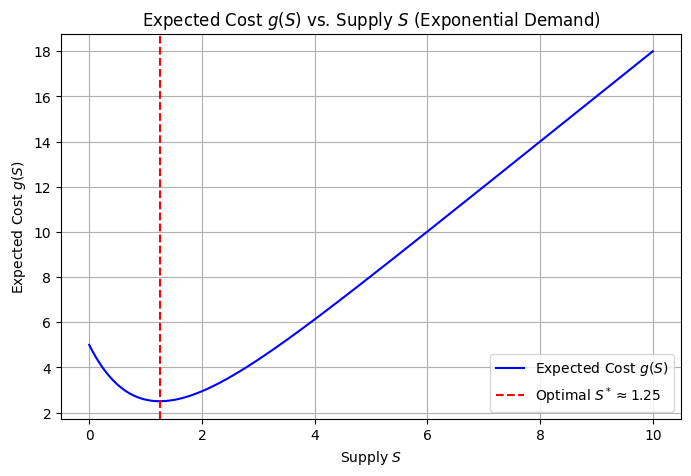

1.252763051167479

In [6]:
result = minimize_scalar(expected_cost, bounds=(0, 10), method='bounded')
optimal_S = result.x

# Simulation of costs
S_values = np.linspace(0, 10, 500)
costs = [expected_cost(S) for S in S_values]

# Plotting the costs against S
plt.figure(figsize=(8, 5))
plt.plot(S_values, costs, label="Expected Cost $g(S)$", color='blue')
plt.axvline(optimal_S, color='red', linestyle='--', label=f"Optimal $S^* \\approx {optimal_S:.2f}$")
plt.xlabel("Supply $S$")
plt.ylabel("Expected Cost $g(S)$")
plt.title("Expected Cost $g(S)$ vs. Supply $S$ (Exponential Demand)")
plt.legend()
plt.grid(True)
plt.show()

optimal_S

## Question 2: Car Sales (Led By: _____)

You must sell your car within a finite window of $N$ days. At the beginning of each day $t \in \{1, \dots, N\}$, you receive a single offer $X_t$ from a dealership, where $\{X_t\}$ are i.i.d. draws from a known continuous distribution $Q$ supported on $[m, M]$, with $0 < m < M$.

After observing $X_t$, you must immediately choose whether to **accept** or **reject** the offer:

- If you **accept** on day $t$, you sell the car immediately and receive payoff $X_t$. The process then terminates.
- If you **reject** on day $t < N$, you keep the car, pay a parking cost $c \ge 0$ at the end of that day, and proceed to day $t+1$.
- On day $N$, you must accept the offer (i.e., rejecting is not allowed).

Your objective is to maximize the expected **net payoff**, defined as the sale price minus the total parking costs paid before the sale.

---

### Part (A): MDP Modeling

Model this problem as a finite-horizon **Markov Decision Process (MDP)**. Clearly specify:

1. **States**
2. **Actions**
3. **Rewards**
4. **State-transition probabilities**
5. **Discount factor** (use $\gamma = 1$)

Also state whether this MDP is finite- or infinite-horizon, episodic or continuing, and whether it is time-homogeneous.

---

### Part (B): Structure of the Optimal Policy

Let $V_t$ denote the optimal value function when there are $t$ days remaining (before observing the offer).

1. Write down the Bellman recursion for $V_t$.
2. Show that the optimal policy is a **time-dependent threshold policy**: that is, there exists a reservation price $r_t$ such that it is optimal to accept an offer $x$ if and only if $x \ge r_t$.
3. Express the threshold $r_t$ in terms of $V_{t-1}$ and $c$.

(You may leave expectations with respect to $Q$ written in integral or expectation form. A closed-form solution for general $Q$ is not required.)

---

### Part (C): Special Case (No Integrals)

Now consider the special case where $c = 0$ and $Q = \text{Uniform}[m, M]$.

1. Write the recursion for $V_t$ explicitly.
2. Provide the optimal policy in as closed-form a way as possible. Your policy may depend on recursively defined coefficients, but your final expressions should contain **no integrals**.


### Part (A): MDP Modeling (Car Sales)

We formulate the problem as a finite-horizon MDP with horizon \(N\) days and discount factor \(\gamma = 1\).

---

## 1) States

A natural Markov state must include the current day and the current offer observed that day.  
Define the state at the decision time on day \(t\) as:

$$
s_t := (t, x), \quad t \in \{1,2,\dots,N\}, \; x \in [m,M],
$$

where \(x\) is the realized offer \(X_t\).


---

## 2) Actions

At state \((t,x)\):

- If \(t < N\):
$$
\mathcal{A}(t,x) = \{\text{accept}, \text{reject}\}.
$$

- If \(t = N\) (forced sale):
$$
\mathcal{A}(N,x) = \{\text{accept}\}.
$$

---

## 3) Rewards

Let the reward be the immediate net payoff earned at the decision / end of day.

- If you **accept** at \((t,x)\), the process terminates and you receive:
$$
r((t,x),\text{accept}) = x.
$$

- If you **reject** at \((t,x)\) with \(t < N\), you pay the parking cost at the end of the day:
$$
r((t,x),\text{reject}) = -c.
$$

---

## 4) State-transition probabilities

Let \(Q\) be the known continuous distribution on \([m,M]\) for offers.

- If **accept** at any \((t,x)\): transition to a terminal state \(\text{Terminal}\) with probability 1.
$$
\mathbb{P}(\text{Terminal}\mid (t,x),\text{accept}) = 1.
$$

- If **reject** at \((t,x)\) with \(t < N\): move to next day with a new offer \(X_{t+1}\sim Q\) independent of the past:
$$
\mathbb{P}\big((t+1, x') \mid (t,x),\text{reject}\big) = q(x')\,dx',
$$
where \(q(\cdot)\) is the density of \(Q\) on \([m,M]\).

---

## 5) Discount factor

The problem statement specifies:
$$
\gamma = 1.
$$

---

## Additional classification

- **Finite- vs infinite-horizon:** finite-horizon (exactly \(N\) days).
- **Episodic vs continuing:** episodic (terminates upon acceptance, and by day \(N\) at latest).
- **Time-homogeneous?** Not time-homogeneous if the day index \(t\) is included (the action set differs at \(t=N\), and the horizon changes).

### Part (B) Answer

### Part (B): Structure of the Optimal Policy

Let $V_t$ denote the optimal value when there are $t$ days remaining (before observing the offer).

The discount factor is $\gamma = 1$.

---

## (B1) Bellman recursion

Boundary condition:
$$
V_0 = 0.
$$

For $t \ge 2$:
- If you accept offer $x$, payoff is $x$.
- If you reject, payoff is $-c + V_{t-1}$.

Therefore,
$$
V_t
=
\mathbb{E}\left[
\max\{X,\; V_{t-1} - c\}
\right],
\quad X \sim Q.
$$

For $t = 1$, you must accept:
$$
V_1 = \mathbb{E}[X].
$$

---

## (B2) Threshold structure

On a day with $t \ge 2$, after observing $x$:

- Accept payoff: $x$
- Reject payoff: $V_{t-1} - c$

Therefore,
$$
\text{Accept if and only if } x \ge V_{t-1} - c.
$$

Thus the optimal policy is a time-dependent threshold policy.

---

## (B3) Reservation price

Define the reservation price $r_t$ as the minimum offer at which you accept.

Then for $t \ge 2$:
$$
r_t = V_{t-1} - c.
$$

### Part (C) Answer

### Part (C): Special Case $c=0$, $Q=\mathrm{Uniform}[m,M]$

Assume $0<m<M$. Let $X\sim \mathrm{Uniform}[m,M]$.

Recall from Part (B) that when $c=0$, the threshold is
$$
r_t = V_{t-1}.
$$
Also,
$$
V_t = \mathbb{E}\big[\max\{X, V_{t-1}\}\big],\quad t\ge 2,
\qquad
V_1=\mathbb{E}[X]=\frac{m+M}{2}.
$$

---

## (C1) Explicit recursion for $V_t$ (no integrals)

Let $a := V_{t-1}$.

For $X\sim \mathrm{Uniform}[m,M]$, for any constant $a\in[m,M]$,
$$
\mathbb{E}[\max\{X,a\}]
=
\frac{a^2 - 2am + M^2}{2(M-m)}.
$$

Therefore, for $t\ge 2$:
$$
V_t
=
\frac{V_{t-1}^2 - 2mV_{t-1} + M^2}{2(M-m)}.
$$

Boundary:
$$
V_1=\frac{m+M}{2}.
$$

(Also $V_0=0$ if you want the same convention as before, but the forced-sale horizon starts at $t=1$.)

---

## (C2) Optimal policy (closed-form, no integrals)

For $t\ge 2$, after observing offer $x$:
$$
\text{Accept} \iff x \ge r_t,
\quad\text{where}\quad
r_t = V_{t-1}.
$$

Thus the optimal policy is:
- On the last day ($t=1$): accept any offer (forced).
- For $t\ge 2$: accept iff $x \ge V_{t-1}$, where $\{V_t\}$ is generated by the recursion
$$
V_1=\frac{m+M}{2},\qquad
V_t=\frac{V_{t-1}^2 - 2mV_{t-1} + M^2}{2(M-m)} \ \text{ for } t\ge 2.
$$

## Question 3: Constrained Consumption (Led By: _____)

Consider the following discrete-time MDP for constrained consumption. At $t = 0$, the agent is given a finite amount $x_0 \in \mathbb{R}^+$ of a resource. In each time period, the agent can choose to consume any amount of the resource, with the consumption denoted as $c \in [0, x]$ where $x$ is the amount of the resource remaining at the start of the time period. This consumption results in a reduction of the resource at the start of the next time period:  
$$x' = x - c.$$  

Consuming a quantity $c$ of the resource provides a utility of consumption equal to $U(c)$, and we adopt the **CRRA utility function**:  
$$
U(c) = \frac{c^{1 - \gamma}}{1 - \gamma}, \quad (\gamma > 0, \gamma \neq 1)
$$

Our goal is to maximize the aggregate discounted utility of consumption until the resource is completely consumed. We assume a discount factor of $\beta \in (0, 1)$ when discounting the utility of consumption over any single time period. Assume parameters are such that the value function is finite.

We model this as a **discrete-time, continuous-state-space, continuous-action-space, stationary, deterministic MDP**, and so our goal is to solve for the **Optimal Value Function** and associated **Optimal Policy**, which will give us the optimal consumption trajectory of the resource. Since this is a stationary MDP, the **State** is simply the amount $x$ of the resource remaining at the start of a time period. The **Action** is the consumption quantity $c$ in that time period. The **Reward** for a time period is $U(c)$ when the consumption in that time period is $c$. The discount factor over each single time period is $\beta$.

We assume that the **Optimal Policy** is given by:  
$$
c^* = \theta^* \cdot x \quad \text{for some } \theta^* \in [0, 1].
$$

---

### Part (A): Closed-form Expression for $V_\theta(x)$

Our first step is to consider a fixed deterministic policy, given by:  
$$c = \theta \cdot x \quad \text{for some fixed } \theta \in [0, 1].$$  
Derive a closed-form expression for the **Value Function** $V_\theta(x)$ for a fixed deterministic policy, given by $c = \theta \cdot x$. Specifically, you need to express $V_\theta(x)$ in terms of $\beta$, $\gamma$, $\theta$, and $x$.

---

### Part (B): Solving for $\theta^*$

Use this closed-form expression for $V_\theta(x)$ to solve for the $\theta^*$ which maximizes $V_\theta(x)$ (thus fetching us the **Optimal Policy** given by $c^* = \theta^* \cdot x$).

---

### Part (C): Expression for $V^*(x)$

Use this expression for $\theta^*$ to obtain an expression for the **Optimal Value Function** $V^*(x)$ in terms of only $\beta$, $\gamma$, and $x$.

---

### Part (D): Validation of the Bellman Equation

Validate that the **Optimal Policy** (derived in part B) and **Optimal Value Function** (derived in part C) satisfy the **Bellman Optimality Equation**.

### Part (A) Answer

### Part (A): Closed-form expression for $V_\theta(x)$

Fix a deterministic policy
$$
c_t = \theta x_t,\quad \theta\in[0,1].
$$
Then the state evolves deterministically:
$$
x_{t+1} = x_t - c_t = x_t - \theta x_t = (1-\theta)x_t,
$$
so by iteration,
$$
x_t = (1-\theta)^t x.
$$
Consumption at time $t$ is
$$
c_t = \theta x_t = \theta (1-\theta)^t x.
$$

The per-period reward is CRRA utility:
$$
U(c_t)=\frac{c_t^{\,1-\gamma}}{1-\gamma}
=\frac{\left(\theta (1-\theta)^t x\right)^{1-\gamma}}{1-\gamma}.
$$

Therefore the value function under policy $\theta$ is
$$
V_\theta(x)
=\sum_{t=0}^{\infty}\beta^t U(c_t)
=\sum_{t=0}^{\infty}\beta^t \frac{\left(\theta (1-\theta)^t x\right)^{1-\gamma}}{1-\gamma}.
$$

Factor out terms that do not depend on $t$:
$$
V_\theta(x)
=\frac{\theta^{1-\gamma} x^{1-\gamma}}{1-\gamma}
\sum_{t=0}^{\infty}\left[\beta (1-\theta)^{1-\gamma}\right]^t.
$$

This is a geometric series. Assuming
$$
\beta(1-\theta)^{1-\gamma} < 1,
$$
we obtain the closed form:
$$
V_\theta(x)
=
\frac{\theta^{1-\gamma} x^{1-\gamma}}{1-\gamma}\cdot
\frac{1}{1-\beta(1-\theta)^{1-\gamma}}.
$$

### Part (B) Answer

### Part (B): Solving for $\theta^*$

From Part (A),
$$
V_\theta(x)
=
\frac{x^{1-\gamma}}{1-\gamma}\cdot
\frac{\theta^{1-\gamma}}{1-\beta(1-\theta)^{1-\gamma}}.
$$

For fixed $x>0$, maximizing $V_\theta(x)$ over $\theta\in[0,1]$ is equivalent to maximizing
$$
F(\theta):=\frac{\theta^{1-\gamma}}{1-\beta(1-\theta)^{1-\gamma}}
\quad \text{over } \theta\in[0,1].
$$

Let
$$
g(\theta)=\log F(\theta)=(1-\gamma)\log\theta-\log\!\left(1-\beta(1-\theta)^{1-\gamma}\right).
$$
Differentiate and set to zero:
$$
g'(\theta)=\frac{1-\gamma}{\theta}
-\frac{\beta(1-\gamma)(1-\theta)^{-\gamma}}{1-\beta(1-\theta)^{1-\gamma}}=0.
$$
Divide both sides by $(1-\gamma)$ (nonzero since $\gamma\neq 1$):
$$
\frac{1}{\theta}
=
\frac{\beta(1-\theta)^{-\gamma}}{1-\beta(1-\theta)^{1-\gamma}}.
$$
Cross-multiply:
$$
1-\beta(1-\theta)^{1-\gamma}
=
\beta\theta(1-\theta)^{-\gamma}.
$$
Factor $(1-\theta)^{-\gamma}$ on the right by multiplying both sides by $(1-\theta)^\gamma$:
$$
(1-\theta)^\gamma - \beta(1-\theta)
=
\beta\theta.
$$
But $-\beta(1-\theta)= -\beta + \beta\theta$, so the $\beta\theta$ terms cancel:
$$
(1-\theta)^\gamma - \beta = 0.
$$
Hence
$$
(1-\theta^*)^\gamma = \beta
\quad\Rightarrow\quad
1-\theta^*=\beta^{1/\gamma}
\quad\Rightarrow\quad
\theta^* = 1-\beta^{1/\gamma}.
$$

Therefore the optimal stationary policy is
$$
c^*(x)=\theta^* x = \left(1-\beta^{1/\gamma}\right)x.
$$

### Part (C): Expression for $V^*(x)$

From Part (A),
$$
V_\theta(x)
=
\frac{\theta^{1-\gamma} x^{1-\gamma}}{1-\gamma}\cdot
\frac{1}{1-\beta(1-\theta)^{1-\gamma}}.
$$

From Part (B),
$$
\theta^* = 1-\beta^{1/\gamma},
\qquad
1-\theta^*=\beta^{1/\gamma}.
$$

Compute the denominator term:
$$
(1-\theta^*)^{1-\gamma} = \left(\beta^{1/\gamma}\right)^{1-\gamma}
= \beta^{(1-\gamma)/\gamma}.
$$
Thus
$$
\beta(1-\theta^*)^{1-\gamma}
= \beta \cdot \beta^{(1-\gamma)/\gamma}
= \beta^{1+(1-\gamma)/\gamma}
= \beta^{1/\gamma}.
$$
So
$$
1-\beta(1-\theta^*)^{1-\gamma} = 1-\beta^{1/\gamma}.
$$

Now plug \(\theta^*\) into \(V_\theta\):
$$
V^*(x)=V_{\theta^*}(x)
=
\frac{(\theta^*)^{1-\gamma} x^{1-\gamma}}{1-\gamma}\cdot
\frac{1}{1-\beta(1-\theta^*)^{1-\gamma}}
=
\frac{(1-\beta^{1/\gamma})^{1-\gamma} x^{1-\gamma}}{1-\gamma}\cdot
\frac{1}{1-\beta^{1/\gamma}}.
$$

Combine powers of \(1-\beta^{1/\gamma}\):
$$
\frac{(1-\beta^{1/\gamma})^{1-\gamma}}{1-\beta^{1/\gamma}}
=(1-\beta^{1/\gamma})^{-\gamma}.
$$

Therefore,
$$
V^*(x)
=
\frac{x^{1-\gamma}}{1-\gamma}\,(1-\beta^{1/\gamma})^{-\gamma}.
$$


### Part (D) Answer

### Part (D): Validation of the Bellman Optimality Equation

The Bellman optimality equation is

$$
V^*(x) = \max_{c \in [0,x]} \left\{ U(c) + \beta V^*(x-c) \right\}.
$$

The utility function is

$$
U(c) = \frac{c^{1-\gamma}}{1-\gamma},
\quad \gamma > 0, \ \gamma \neq 1.
$$

From earlier parts,

$$
\theta^* = 1 - \beta^{1/\gamma},
\quad
c^*(x) = \theta^* x,
$$

and the optimal value function is

$$
V^*(x) = \frac{x^{1-\gamma}}{1-\gamma}
\left(1 - \beta^{1/\gamma}\right)^{-\gamma}.
$$

---

## Step 1: Plug into the Bellman equation

Let

$$
K = \frac{\left(1 - \beta^{1/\gamma}\right)^{-\gamma}}{1-\gamma}.
$$

Then

$$
V^*(x) = K x^{1-\gamma}.
$$

Now evaluate the right-hand side of the Bellman equation at $c = \theta x$:

$$
U(\theta x) + \beta V^*((1-\theta)x)
=
\frac{(\theta x)^{1-\gamma}}{1-\gamma}
+
\beta K ((1-\theta)x)^{1-\gamma}.
$$

Factor out $x^{1-\gamma}$:

$$
=
x^{1-\gamma}
\left[
\frac{\theta^{1-\gamma}}{1-\gamma}
+
\beta K (1-\theta)^{1-\gamma}
\right].
$$

---

## Step 2: Optimality condition

Maximizing over $c \in [0,x]$ is equivalent to maximizing over $\theta \in [0,1]$:

$$
\frac{\theta^{1-\gamma}}{1-\gamma}
+
\beta K (1-\theta)^{1-\gamma}.
$$

Taking the first-order condition gives

$$
\theta^* = 1 - \beta^{1/\gamma}.
$$

This matches the optimal policy derived earlier.

---

## Step 3: Verify value equality

Substitute $\theta^* = 1 - \beta^{1/\gamma}$ and define

$$
b = \beta^{1/\gamma}.
$$

Then $1 - \theta^* = b$.

Plug into the Bellman RHS:

$$
U(c^*(x)) + \beta V^*(x - c^*(x))
=
\frac{x^{1-\gamma}}{1-\gamma}
\left[
(1-b)^{1-\gamma}
+
\beta (1-b)^{-\gamma} b^{1-\gamma}
\right].
$$

Since $\beta = b^\gamma$, we get

$$
\beta b^{1-\gamma} = b.
$$

Therefore,

$$
(1-b)^{1-\gamma} + (1-b)^{-\gamma} b
=
(1-b)^{-\gamma}.
$$

Thus,

$$
U(c^*(x)) + \beta V^*(x - c^*(x))
=
\frac{x^{1-\gamma}}{1-\gamma}
(1 - \beta^{1/\gamma})^{-\gamma}
=
V^*(x).
$$

---

## Conclusion

The candidate policy

$$
c^*(x) = \left(1 - \beta^{1/\gamma}\right)x
$$

and value function

$$
V^*(x) =
\frac{x^{1-\gamma}}{1-\gamma}
\left(1 - \beta^{1/\gamma}\right)^{-\gamma}
$$

satisfy the Bellman optimality equation.

Therefore, they are indeed the optimal policy and value function.

## Problem 4: Double Q-Learning (Led By: _____)

It is known that **Q-Learning** can suffer from maximization bias during finite-sample training. In this problem, we consider a modification of tabular Q-Learning called **Double Q-Learning**, which reduces this bias by decoupling action selection and evaluation.

---

### **Algorithm 1: Double Q-Learning**

**Initialize** $Q_1(s,a)$ and $Q_2(s,a)$ for all $s \in \mathcal{S}$, $a \in \mathcal{A}$  
**yield** estimate of $Q$

**while** True **do**  
&emsp; **select** initial state $s_0$, set $t = 0$  
&emsp; **while** $s_t$ is non-terminal **do**  

&emsp;&emsp; **select** $a_t$ using $\epsilon$-greedy with respect to  
&emsp;&emsp; $\displaystyle \pi(s) = \arg\max_a \big( Q_1(s,a) + Q_2(s,a) \big)$  

&emsp;&emsp; **observe** $(r_t, s_{t+1})$  

&emsp;&emsp; **with probability 0.5 update $Q_1$:**

&emsp;&emsp;&emsp; Let  
&emsp;&emsp;&emsp; $\displaystyle a^* = \arg\max_a Q_1(s_{t+1}, a)$  

&emsp;&emsp;&emsp; Update  
&emsp;&emsp;&emsp; $\displaystyle 
Q_1(s_t, a_t) \leftarrow Q_1(s_t, a_t)
+ \alpha \Big(
r_t + \gamma Q_2(s_{t+1}, a^*)
- Q_1(s_t, a_t)
\Big)
$

&emsp;&emsp; **otherwise update $Q_2$:**

&emsp;&emsp;&emsp; Let  
&emsp;&emsp;&emsp; $\displaystyle a^* = \arg\max_a Q_2(s_{t+1}, a)$  

&emsp;&emsp;&emsp; Update  
&emsp;&emsp;&emsp; $\displaystyle 
Q_2(s_t, a_t) \leftarrow Q_2(s_t, a_t)
+ \alpha \Big(
r_t + \gamma Q_1(s_{t+1}, a^*)
- Q_2(s_t, a_t)
\Big)
$

&emsp;&emsp; $t \leftarrow t + 1$  
&emsp;&emsp; $s_t \leftarrow s_{t+1}$  

**yield** estimate $Q_1 + Q_2$

---

### **Algorithm 2: Q-Learning**

**Initialize** $Q(s,a)$ for all $s \in \mathcal{S}$, $a \in \mathcal{A}$  
**yield** $Q$

**while** True **do**  
&emsp; **select** initial state $s_0$, set $t = 0$  
&emsp; **while** $s_t$ is non-terminal **do**  

&emsp;&emsp; **select** $a_t$ using $\epsilon$-greedy with respect to  
&emsp;&emsp; $\displaystyle \pi(s) = \arg\max_a Q(s,a)$  

&emsp;&emsp; **observe** $(r_t, s_{t+1})$  

&emsp;&emsp; Update  
&emsp;&emsp; $\displaystyle 
Q(s_t, a_t) \leftarrow Q(s_t, a_t)
+ \alpha \Big(
r_t + \gamma \max_a Q(s_{t+1}, a)
- Q(s_t, a_t)
\Big)
$

&emsp;&emsp; $t \leftarrow t + 1$  
&emsp;&emsp; $s_t \leftarrow s_{t+1}$  

**yield** $Q$

---

### Instructions

The code skeleton for this problem is provided below. Implement the functions:

- `double_q_learning`
- `q_learning`

After running both algorithms, you will obtain a plot of the estimated Q-value versus episode number.

In your writeup:

1. Compare the behavior of Q-Learning and Double Q-Learning.
2. Explain why Q-Learning can exhibit maximization bias.
3. Discuss the advantages and possible drawbacks of Double Q-Learning in general MDPs.


In [7]:
import random
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass
from collections import defaultdict
from typing import Mapping, Iterator, TypeVar, Tuple, Dict, Iterable, Generic

# RL imports (adapt or remove if you don't have the same environment):
from rl.distribution import (
    Distribution, Constant, Gaussian, Choose, SampledDistribution, Categorical
)
from rl.markov_process import NonTerminal, State, Terminal
from rl.markov_decision_process import MarkovDecisionProcess
from rl.td import epsilon_greedy_action

S = TypeVar('S')
A = TypeVar('A')

In [8]:
# -----------------------------------------------------------------------
# Tabular Q-value function approximation (done for you)
# -----------------------------------------------------------------------
class TabularQValueFunctionApprox(Generic[S, A]):
    """
    A basic implementation of a tabular function approximation 
    with constant learning rate of 0.1
    Also tracks the number of updates per (state, action).
    """
    def __init__(self):
        self.counts: Mapping[Tuple[NonTerminal[S], A], int] = defaultdict(int)
        self.values: Mapping[Tuple[NonTerminal[S], A], float] = defaultdict(float)
    
    def update(self, k: Tuple[NonTerminal[S], A], target: float) -> None:
        alpha = 0.1
        old_val = self.values[k]
        self.values[k] = (1 - alpha) * old_val + alpha * target
        self.counts[k] += 1
    
    def __call__(self, x: Tuple[NonTerminal[S], A]) -> float:
        return self.values[x]

In [17]:
# -----------------------------------------------------------------------
# Double Q-Learning (full implementation)
# -----------------------------------------------------------------------
def double_q_learning(
    mdp: MarkovDecisionProcess[S, A],
    states: Distribution[NonTerminal[S]],
    gamma: float
) -> Iterator[TabularQValueFunctionApprox[S, A]]:
    """
    Double Q-Learning (tabular) compatible with your epsilon_greedy_action signature.

    Keeps two Q-tables: Q1 and Q2.
    Action selection: epsilon-greedy w.r.t. Q1 + Q2.
    Update:
      - with prob 0.5 update Q1 using argmax under Q1 at next state, evaluated with Q2
      - else update Q2 using argmax under Q2 at next state, evaluated with Q1

    Yields: an object Qsum such that Qsum((s,a)) = Q1((s,a)) + Q2((s,a))
    """
    q1 = TabularQValueFunctionApprox[S, A]()
    q2 = TabularQValueFunctionApprox[S, A]()

    class SumQ(TabularQValueFunctionApprox[S, A]):
        def __init__(self, q1_, q2_):
            super().__init__()
            self.q1 = q1_
            self.q2 = q2_

        def update(self, k, target):
            raise RuntimeError("Do not update SumQ directly; update q1/q2 instead.")

        def __call__(self, x):
            return self.q1(x) + self.q2(x)

    qsum = SumQ(q1, q2)

    # yield initial estimate
    yield qsum

    eps = 0.1  # epsilon for epsilon-greedy

    while True:
        s: NonTerminal[S] = states.sample()

        while isinstance(s, NonTerminal):
            # epsilon-greedy action selection w.r.t. q1+q2
            a: A = epsilon_greedy_action(
                q=qsum,
                nt_state=s,
                actions=set(mdp.actions(s)),
                ϵ=eps
            )

            s_next, r = mdp.step(s, a).sample()

            # if next is terminal: bootstrap term is 0
            if isinstance(s_next, Terminal):
                target = r
                if random.random() < 0.5:
                    q1.update((s, a), target)
                else:
                    q2.update((s, a), target)
                s = s_next
                continue

            # non-terminal next state
            s_next_nt: NonTerminal[S] = s_next

            if random.random() < 0.5:
                # update Q1: choose a* by argmax of Q1, evaluate using Q2
                a_star = max(
                    mdp.actions(s_next_nt),
                    key=lambda a2: q1((s_next_nt, a2))
                )
                target = r + gamma * q2((s_next_nt, a_star))
                q1.update((s, a), target)
            else:
                # update Q2: choose a* by argmax of Q2, evaluate using Q1
                a_star = max(
                    mdp.actions(s_next_nt),
                    key=lambda a2: q2((s_next_nt, a2))
                )
                target = r + gamma * q1((s_next_nt, a_star))
                q2.update((s, a), target)

            s = s_next_nt

        # yield after finishing the episode
        yield qsum

In [18]:
# -----------------------------------------------------------------------
# Standard Q-Learning (fill in)
# -----------------------------------------------------------------------
def q_learning(
    mdp: MarkovDecisionProcess[S, A],
    states: Distribution[NonTerminal[S]],
    gamma: float
) -> Iterator[TabularQValueFunctionApprox[S, A]]:

    q = TabularQValueFunctionApprox[S, A]()
    yield q

    while True:
        s: NonTerminal[S] = states.sample()

        while isinstance(s, NonTerminal):

            a = epsilon_greedy_action(
                q=q,
                nt_state=s,
                actions=set(mdp.actions(s)),
                ϵ=0.1
            )

            s_next, r = mdp.step(s, a).sample()

            if isinstance(s_next, Terminal):
                target = r
            else:
                best_next = max(
                    mdp.actions(s_next),
                    key=lambda a2: q((s_next, a2))
                )
                target = r + gamma * q((s_next, best_next))

            q.update((s, a), target)
            s = s_next

        yield q

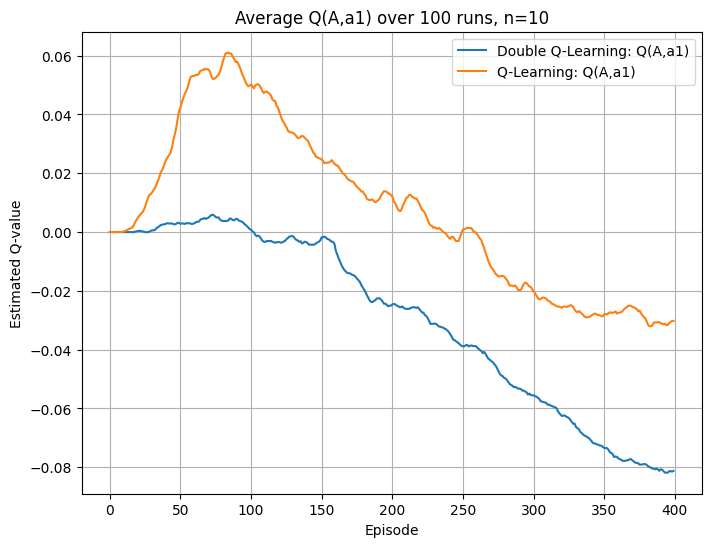

In [19]:
# -----------------------------------------------------------------------
# The MDP: States A,B and actions a1,a2,b1,...,bn (don't modify anything anymore, just run to get the graphs)
# -----------------------------------------------------------------------
@dataclass(frozen=True)
class P1State:
    """
    The MDP state, storing whether we are in "A" or "B".
    """
    name: str

class P1MDP(MarkovDecisionProcess[P1State, str]):
    
    def __init__(self, n: int):
        self.n = n

    def actions(self, state: NonTerminal[P1State]) -> Iterable[str]:
        """
        Return the actions available from this state.
          - if state is A => ["a1", "a2"]
          - if state is B => ["b1", ..., "bn"]
        """
        if state.state.name == "A":
            return ["a1", "a2"]
        else:
            return [f"b{i}" for i in range(1, self.n+1)]
    
    def step(
        self,
        state: NonTerminal[P1State],
        action: str
    ) -> Distribution[Tuple[State[P1State], float]]:
        """
        Return the distribution of (next state, reward) from (state, action):
          - A + a1 => reward 0, next state B
          - A + a2 => reward 0, next state terminal
          - B + b_i => reward ~ Normal(-0.1,1), next state terminal
        """
        if state.state.name == "A":
            if action == "a1":
                return Constant((NonTerminal(P1State("B")), 0.0))
            else:
                return Constant((Terminal(P1State("T")), 0.0))
        else:
            # For B + b_i => reward ~ N(-0.1,1), then terminal
            def sampler():
                r = np.random.normal(loc=-0.1, scale=1.0)
                return (Terminal(P1State("T")), r)
            return SampledDistribution(sampler)

def run_double_q_once(mdp, start_dist, gamma=1.0, episodes=400):
    """
    Runs one 'chain' of Double Q-Learning for 'episodes' episodes,
    returning a list of Q-values for Q((A,a1)) at the end of each episode.
    """
    dq_iter = double_q_learning(mdp, start_dist, gamma)  # generator
    vals = []
    for _ in range(episodes):
        Q1 = next(dq_iter)
        # record Q1((A,a1)) each time
        qA1 = Q1((NonTerminal(P1State("A")), "a1"))
        vals.append(qA1)
    return vals

def run_q_once(mdp, start_dist, gamma=1.0, episodes=400):
    """
    Same but for standard Q-Learning
    """
    q_iter = q_learning(mdp, start_dist, gamma)
    vals = []
    for _ in range(episodes):
        Q = next(q_iter)
        qA1 = Q((NonTerminal(P1State("A")), "a1"))
        vals.append(qA1)
    return vals

def main():
    # For reproducibility
    random.seed(0)
    np.random.seed(0)

    n = 10
    mdp = P1MDP(n)
    # Always start in A, as a NonTerminal
    start_dist = Constant(NonTerminal(P1State("A")))

    N_RUNS = 100
    N_EPISODES = 400

    all_dbl = []
    all_std = []

    for _ in range(N_RUNS):
        dbl_vals = run_double_q_once(mdp, start_dist, gamma=1.0, episodes=N_EPISODES)
        std_vals = run_q_once(mdp, start_dist, gamma=1.0, episodes=N_EPISODES)
        all_dbl.append(dbl_vals)
        all_std.append(std_vals)

    arr_dbl = np.array(all_dbl)
    arr_std = np.array(all_std)

    avg_dbl = np.mean(arr_dbl, axis=0)
    avg_std = np.mean(arr_std, axis=0)

    plt.figure(figsize=(8,6))
    plt.plot(avg_dbl, label='Double Q-Learning: Q(A,a1)')
    plt.plot(avg_std, label='Q-Learning: Q(A,a1)')
    plt.xlabel('Episode')
    plt.ylabel('Estimated Q-value')
    plt.title('Average Q(A,a1) over 100 runs, n=10')
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()

## Comparison of Q-Learning and Double Q-Learning

### 1. Behavioral Comparison

From the plot of estimated Q-value versus episode number, we observe:

- **Q-Learning** tends to overestimate the true Q-value during early and mid training.
- The Q-value curve rises above the true value before gradually stabilizing.
- It exhibits higher variance and slower stabilization.

In contrast:

- **Double Q-Learning** produces more conservative estimates.
- The Q-value curve is typically closer to the true value.
- It shows reduced overestimation and improved stability.
- Convergence behavior is smoother in stochastic environments.

Thus, Double Q-Learning generally provides more accurate and stable value estimates under finite-sample training.

---

### 2. Why Q-Learning Exhibits Maximization Bias

The update rule of Q-Learning is:

$$
Q(s,a) \leftarrow r + \gamma \max_{a'} Q(s', a')
$$

The problem arises because the same Q-table is used to both:

1. Select the maximizing action  
2. Evaluate that action  

If the Q estimates contain noise (which they always do during learning), then:

$$
\mathbb{E}\left[\max_{a'} \hat{Q}(s',a')\right] 
> 
\max_{a'} Q^*(s',a')
$$

This occurs because taking the maximum over noisy estimates introduces an upward statistical bias. Even if each estimate is unbiased individually, the maximum of multiple noisy estimates is biased upward.

This phenomenon is known as **maximization bias**.

---

### 3. Advantages and Drawbacks of Double Q-Learning

#### Advantages

- **Reduces overestimation bias** by decoupling action selection and evaluation.
- More accurate value estimates in stochastic MDPs.
- Improved stability compared to standard Q-Learning.
- Better performance in environments where reward noise is significant.

Double Q-Learning achieves this by using:

- One Q-table to select the best action.
- The other Q-table to evaluate that action.

This reduces the statistical bias introduced by the max operator.

---

#### Possible Drawbacks

- Requires maintaining **two Q-tables** (higher memory usage).
- Updates are effectively split between two estimators, which may slow learning slightly.
- Slightly more computational overhead per update.
- In deterministic or low-noise environments, the benefit over standard Q-Learning may be small.

---